# Linear shallow water Fourier solver for predictability games

Top version is more modular but long, versions below were simpler and clearer. All from calude.ai conversations BEM Mar 31, 2025

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

class WaveSimulator:
    """A modular shallow water wave simulator.
    
    This class makes it easy to create, visualize, and animate
    interfering shallow water waves.
    """
    
    def __init__(self, grid_size=128, domain_size=2*np.pi, gravity=9.81, mean_depth=1.0):
        """Initialize the wave simulator.
        
        Args:
            grid_size: Number of grid points in each dimension
            domain_size: Size of the square domain
            gravity: Gravitational acceleration
            mean_depth: Mean water depth
        """
        self.grid_size = grid_size
        self.L = domain_size
        self.dx = self.L / grid_size
        self.g = gravity
        self.H0 = mean_depth
        
        # Create grid in physical space
        x = np.linspace(0, self.L, grid_size, endpoint=False)
        y = np.linspace(0, self.L, grid_size, endpoint=False)
        self.X, self.Y = np.meshgrid(x, y)
        
        # Create wavenumber grids
        kx = np.fft.fftfreq(grid_size, d=self.dx/self.L)
        ky = np.fft.fftfreq(grid_size, d=self.dx/self.L)
        self.KX, self.KY = np.meshgrid(kx, ky)
        self.K_squared = self.KX**2 + self.KY**2
        
        # Compute dispersion relation for shallow water waves
        self.omega = np.sqrt(self.g * self.H0 * self.K_squared)
        # Handle k=0 mode to avoid division issues
        self.omega[0, 0] = 1.0
        
        # Initialize wave height and time derivative
        self.reset_waves()
    
    def reset_waves(self):
        """Reset wave height and time derivative to zero."""
        self.h = np.zeros((self.grid_size, self.grid_size))
        self.h_t = np.zeros((self.grid_size, self.grid_size))
        self.waves_added = 0
    
    def add_traveling_wave(self, amplitude, k_x, k_y, phase=0, direction=1):
        """Add a traveling wave with specified parameters.
        
        Args:
            amplitude: Wave amplitude
            k_x, k_y: Wavenumbers in x and y directions
            phase: Initial phase offset
            direction: 1 for positive direction, -1 for negative direction
        """
        omega_val = np.sqrt(self.g * self.H0 * (k_x**2 + k_y**2))
        
        self.h += amplitude * np.cos(k_x * self.X + k_y * self.Y + phase)
        self.h_t += -direction * amplitude * omega_val * np.sin(k_x * self.X + k_y * self.Y + phase)
        
        self.waves_added += 1
        return self
    
    def add_circular_wave(self, amplitude, wavenumber, center_x=None, center_y=None, num_components=16):
        """Add a circular wave emanating from a specified center.
        
        Args:
            amplitude: Wave amplitude
            wavenumber: Radial wavenumber
            center_x, center_y: Center coordinates (defaults to domain center)
            num_components: Number of directional components to approximate circular wave
        """
        if center_x is None:
            center_x = self.L / 2
        if center_y is None:
            center_y = self.L / 2
        
        # Create radial wave by summing directional components
        for theta in np.linspace(0, 2*np.pi, num_components, endpoint=False):
            k_x = wavenumber * np.cos(theta)
            k_y = wavenumber * np.sin(theta)
            
            # Adjust phase to make wave emanate from the center
            phase = -k_x * center_x - k_y * center_y
            
            self.add_traveling_wave(
                amplitude=amplitude/num_components,
                k_x=k_x, k_y=k_y,
                phase=phase,
                direction=1
            )
        
        self.waves_added += 1
        return self
    
    def add_standing_wave(self, amplitude, k_x, k_y, phase=0):
        """Add a standing wave with specified parameters.
        
        Args:
            amplitude: Wave amplitude
            k_x, k_y: Wavenumbers in x and y directions
            phase: Initial phase offset
        """
        # Standing wave = two traveling waves in opposite directions
        self.h += amplitude * np.cos(k_x * self.X + k_y * self.Y + phase)
        # For standing wave, h_t = 0 initially
        
        self.waves_added += 1
        return self
    
    def prepare_simulation(self):
        """Prepare for simulation by computing Fourier coefficients."""
        # Convert to Fourier space
        self.h_hat = np.fft.fft2(self.h)
        self.h_t_hat = np.fft.fft2(self.h_t)
        
        # Define coefficients for traveling waves in opposite directions
        self.A = np.zeros_like(self.h_hat, dtype=complex)
        self.B = np.zeros_like(self.h_hat, dtype=complex)
        
        # Handle non-zero wavenumbers
        mask = (self.K_squared > 0)
        self.A[mask] = 0.5 * (self.h_hat[mask] - 1j * self.h_t_hat[mask] / self.omega[mask])
        self.B[mask] = 0.5 * (self.h_hat[mask] + 1j * self.h_t_hat[mask] / self.omega[mask])
        
        # Handle k=0 mode separately (mean value)
        self.A[0, 0] = self.h_hat[0, 0]
        self.B[0, 0] = 0
    
    def compute_solution_at_time(self, t):
        """Compute the solution at time t.
        
        Args:
            t: Time at which to compute the solution
            
        Returns:
            Array of wave heights at time t
        """
        # Compute solution at time t
        h_hat_t = self.A * np.exp(-1j * self.omega * t) + self.B * np.exp(1j * self.omega * t)
        
        # Transform back to physical space
        h_t = np.real(np.fft.ifft2(h_hat_t)) + self.H0
        return h_t
    
    def create_animation(self, duration=5.0, fps=20, cmap='viridis', figsize=(10, 8), levels=20):
        """Create and display an animation of the wave propagation.
        
        Args:
            duration: Duration of animation in seconds
            fps: Frames per second
            cmap: Colormap for visualization
            figsize: Figure size
            levels: Number of contour levels
            
        Returns:
            Animation object
        """
        if self.waves_added == 0:
            print("No waves added. Add waves before creating animation.")
            return None
        
        # Prepare for simulation
        self.prepare_simulation()
        
        # Create figure and initial plot
        fig, ax = plt.subplots(figsize=figsize)
        contour = ax.contourf(self.X, self.Y, self.compute_solution_at_time(0), levels, cmap=cmap)
        title = ax.set_title(f"Shallow Water Waves: t = 0.00")
        fig.colorbar(contour)
        
        # Number of frames
        frames = int(duration * fps)
        dt = duration / frames
        
        def update(frame):
            t = frame * dt
            h_t = self.compute_solution_at_time(t)
            
            # Clear previous plot
            ax.clear()
            contour = ax.contourf(self.X, self.Y, h_t, levels, cmap=cmap)
            ax.set_title(f"Shallow Water Waves: t = {t:.2f}")
            return contour,
        
        # Create animation
        ani = FuncAnimation(fig, update, frames=frames, blit=False, interval=1000/fps)
        plt.close()  # Prevent the figure from being displayed twice
        return ani
    
    def display_animation(self, ani):
        """Display the animation in a Jupyter notebook."""
        return HTML(ani.to_jshtml())
    
    def plot_current_state(self, title="Initial Wave Configuration", cmap='viridis', figsize=(10, 8), levels=20):
        """Plot the current state of the wave field.
        
        Args:
            title: Plot title
            cmap: Colormap for visualization
            figsize: Figure size
            levels: Number of contour levels
        """
        plt.figure(figsize=figsize)
        contour = plt.contourf(self.X, self.Y, self.h + self.H0, levels, cmap=cmap)
        plt.title(title)
        plt.colorbar(contour)
        plt.tight_layout()
        plt.show()

In [ ]:
# Import the wave simulator
from IPython.display import HTML

# Create a simulator with default parameters
simulator = WaveSimulator(grid_size=128)

# Add some waves
simulator.add_traveling_wave(amplitude=0.1, k_x=3, k_y=0, phase=0)             # Wave traveling right
simulator.add_traveling_wave(amplitude=0.08, k_x=0, k_y=2, phase=np.pi/4)      # Wave traveling up
simulator.add_circular_wave(amplitude=0.12, wavenumber=4)                      # Circular wave from center
simulator.add_standing_wave(amplitude=0.05, k_x=1, k_y=1, phase=np.pi/2)       # Standing wave

# Visualize initial wave configuration
simulator.plot_current_state("Initial Wave Configuration")

# Create and display animation
animation = simulator.create_animation(duration=5.0, fps=30)
HTML(animation.to_jshtml())

In [ ]:
# Experiment: Wave Interference Patterns

# Create a simulator
sim = WaveSimulator(grid_size=128)

# Reset any previous waves (optional, simulator starts with no waves)
sim.reset_waves()

# EXPERIMENT 1: Two Crossing Waves
# Add two waves traveling perpendicular to each other
sim.add_traveling_wave(amplitude=0.1, k_x=3, k_y=0)  # Wave traveling along x-axis
sim.add_traveling_wave(amplitude=0.1, k_x=0, k_y=3)  # Wave traveling along y-axis

# Create and display animation
animation1 = sim.create_animation(duration=5.0, fps=20, cmap='viridis')
HTML(animation1.to_jshtml())

In [ ]:
# EXPERIMENT 2: Circular Waves with Different Origins
# Reset for new experiment
sim.reset_waves()

# Add two circular waves from different origins
sim.add_circular_wave(amplitude=0.1, wavenumber=5, center_x=np.pi/2, center_y=np.pi/2)
sim.add_circular_wave(amplitude=0.1, wavenumber=5, center_x=3*np.pi/2, center_y=3*np.pi/2)

# Create and display animation
animation2 = sim.create_animation(duration=5.0, fps=20, cmap='coolwarm')
HTML(animation2.to_jshtml())

In [ ]:
# EXPERIMENT 3: Standing Wave Pattern, seems zany 
# Reset for new experiment
sim.reset_waves()

# Create a standing wave pattern
sim.add_standing_wave(amplitude=0.1, k_x=2, k_y=0)
sim.add_standing_wave(amplitude=0.1, k_x=0, k_y=2)

# Create and display animation
animation3 = sim.create_animation(duration=5.0, fps=20, cmap='plasma')
HTML(animation3.to_jshtml())

# This version is clean and simple

Some edge effect, how can that come in with a periodic array and fft? 

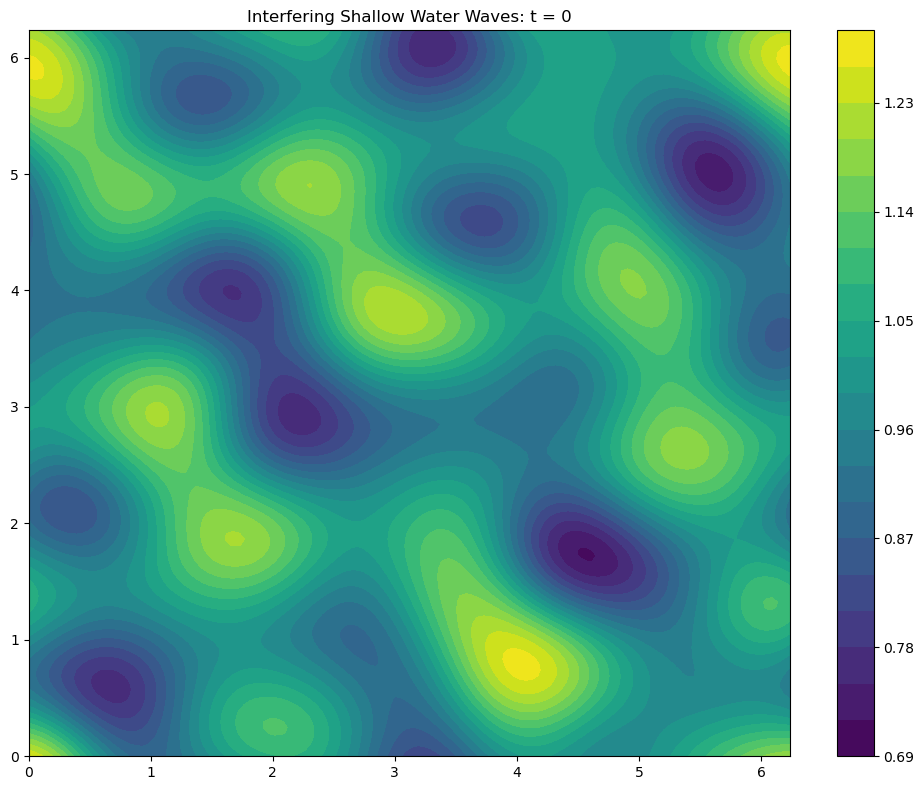

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Set parameters
grid_size = 128
L = 2 * np.pi  # Domain size
dx = L / grid_size
g = 9.81  # Gravity
H0 = 1.0  # Mean water depth

# Create grid in physical space
x = np.linspace(0, L, grid_size, endpoint=False)
y = np.linspace(0, L, grid_size, endpoint=False)
X, Y = np.meshgrid(x, y)

# Create wavenumber grids
kx = np.fft.fftfreq(grid_size, d=dx/L)
ky = np.fft.fftfreq(grid_size, d=dx/L)
KX, KY = np.meshgrid(kx, ky)
K_squared = KX**2 + KY**2

# Compute dispersion relation for shallow water waves
omega = np.sqrt(g * H0 * K_squared)
# Handle k=0 mode to avoid division issues
omega[0, 0] = 1.0  # Arbitrary non-zero value for k=0 mode

# Initialize wave function h and its time derivative h_t
h = np.zeros((grid_size, grid_size))
h_t = np.zeros((grid_size, grid_size))

# Define a function to add a traveling wave with specified parameters
def add_traveling_wave(h, h_t, amplitude, k_x, k_y, phase=0, direction=1):
    """
    Add a traveling wave to the height field h and its time derivative h_t
    
    Parameters:
    -----------
    h, h_t : arrays
        Height field and its time derivative
    amplitude : float
        Wave amplitude
    k_x, k_y : float
        Wavenumbers in x and y directions
    phase : float
        Initial phase offset
    direction : int
        1 for positive direction, -1 for negative direction
    """
    omega_val = np.sqrt(g * H0 * (k_x**2 + k_y**2))
    
    h += amplitude * np.cos(k_x * X + k_y * Y + phase)
    h_t += -direction * amplitude * omega_val * np.sin(k_x * X + k_y * Y + phase)
    
    return h, h_t

# Add multiple traveling waves
# Wave 1: Traveling right (positive x)
h, h_t = add_traveling_wave(h, h_t, amplitude=0.1, k_x=3, k_y=1, phase=0, direction=1)

# Wave 2: Traveling up (positive y)
h, h_t = add_traveling_wave(h, h_t, amplitude=0.08, k_x=1, k_y=2, phase=np.pi/4, direction=1)

# Wave 3: Traveling diagonally
h, h_t = add_traveling_wave(h, h_t, amplitude=0.05, k_x=2, k_y=3, phase=np.pi/2, direction=1)

# Wave 4: Traveling in opposite diagonal (creating interference)
h, h_t = add_traveling_wave(h, h_t, amplitude=0.06, k_x=-1, k_y=4, phase=np.pi/3, direction=1)

# Wave 5: Circular wave from center (using higher wavenumbers)
amplitude_circular = 0.07
for theta in np.linspace(0, 2*np.pi, 16, endpoint=False):
    k_x = 5 * np.cos(theta)
    k_y = 5 * np.sin(theta)
    h, h_t = add_traveling_wave(h, h_t, amplitude=amplitude_circular/16, k_x=k_x, k_y=k_y, 
                               phase=0, direction=1)

# Convert to Fourier space
h_hat = np.fft.fft2(h)
h_t_hat = np.fft.fft2(h_t)

# Define a function to compute the solution at time t
def compute_solution_at_time(t):
    """Compute the solution at time t using the analytical approach."""
    # Define coefficients for traveling waves in opposite directions
    A = np.zeros_like(h_hat, dtype=complex)
    B = np.zeros_like(h_hat, dtype=complex)
    
    # Handle non-zero wavenumbers
    mask = (K_squared > 0)
    A[mask] = 0.5 * (h_hat[mask] - 1j * h_t_hat[mask] / omega[mask])
    B[mask] = 0.5 * (h_hat[mask] + 1j * h_t_hat[mask] / omega[mask])
    
    # Handle k=0 mode separately (mean value)
    A[0, 0] = h_hat[0, 0]
    B[0, 0] = 0
    
    # Compute solution at time t
    h_hat_t = A * np.exp(-1j * omega * t) + B * np.exp(1j * omega * t)
    
    # Transform back to physical space
    h_t = np.real(np.fft.ifft2(h_hat_t)) + H0
    return h_t

# Create animation
fig, ax = plt.subplots(figsize=(10, 8))
contour = ax.contourf(X, Y, compute_solution_at_time(0), 20, cmap='viridis')
title = ax.set_title(f"Interfering Shallow Water Waves: t = 0")
fig.colorbar(contour)

def update(frame):
    t = frame * 0.05  # Time step
    h_t = compute_solution_at_time(t)
    
    # Clear previous plot
    ax.clear()
    contour = ax.contourf(X, Y, h_t, 20, cmap='viridis')
    ax.set_title(f"Interfering Shallow Water Waves: t = {t:.2f}")
    return contour,

# Create animation
ani = FuncAnimation(fig, update, frames=100, blit=False, interval=50)
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import HTML
HTML(ani.to_jshtml())

# Uncomment to save animation
# anim.save('linear_shallow_water.mp4', writer='ffmpeg', fps=20)

# Even simpler, single wave 

/Users/bmapes/.local/share/mamba/envs/evo-conv/lib/python3.11/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


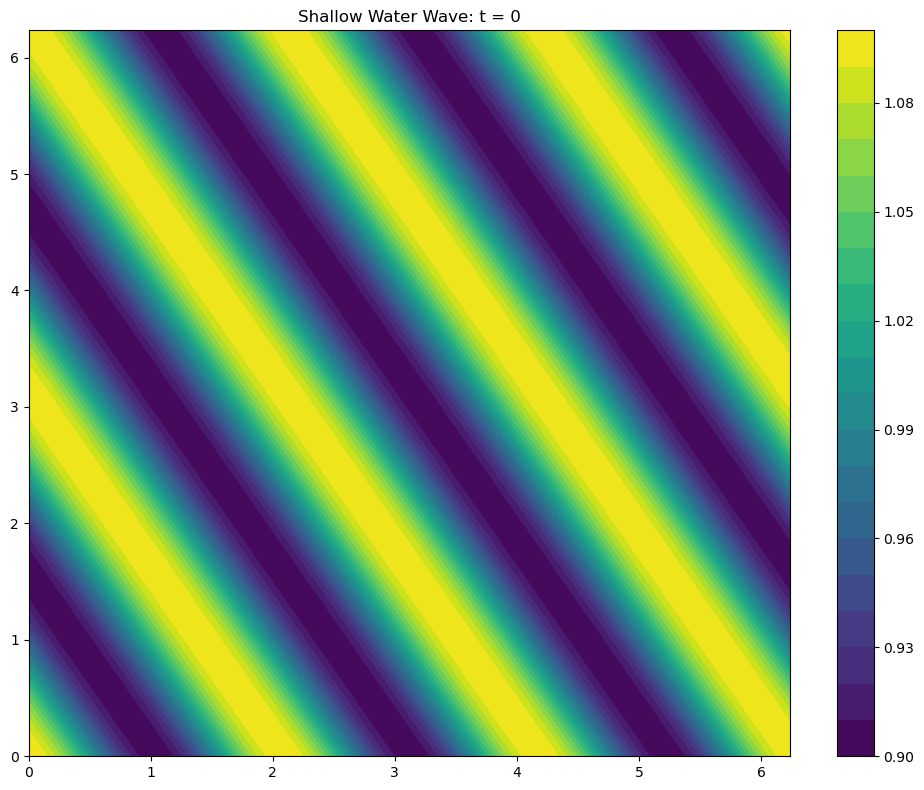

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Set parameters
grid_size = 128
L = 2 * np.pi  # Domain size
dx = L / grid_size
g = 9.81  # Gravity
H0 = 1.0  # Mean water depth
amplitude = 0.1  # Wave amplitude

# Create grid in physical space
x = np.linspace(0, L, grid_size, endpoint=False)
y = np.linspace(0, L, grid_size, endpoint=False)
X, Y = np.meshgrid(x, y)

# Create wavenumber grids
kx = np.fft.fftfreq(grid_size, d=dx/L)
ky = np.fft.fftfreq(grid_size, d=dx/L)
KX, KY = np.meshgrid(kx, ky)
K_squared = KX**2 + KY**2

# Compute dispersion relation for shallow water waves
omega = np.sqrt(g * H0 * K_squared)
# Handle k=0 mode to avoid division issues
omega[0, 0] = 1.0  # Arbitrary non-zero value for k=0 mode

# Initialize wave function h and its time derivative h_t
h = np.zeros((grid_size, grid_size))
h_t = np.zeros((grid_size, grid_size))

# Set traveling wave initial conditions
k_x, k_y = 3, 2  # Wavenumbers
phase = 0
omega_val = np.sqrt(g * H0 * (k_x**2 + k_y**2))
h += amplitude * np.cos(k_x * X + k_y * Y + phase)
h_t += -amplitude * omega_val * np.sin(k_x * X + k_y * Y + phase)  # Negative for positive propagation

# Convert to Fourier space
h_hat = np.fft.fft2(h)
h_t_hat = np.fft.fft2(h_t)

# Define a function to compute the exact solution at time t
def compute_solution_at_time(t):
    """Compute the exact solution at time t using the analytical approach."""
    # Define coefficients for traveling waves in opposite directions
    # Careful handling of zero wavenumbers
    A = np.zeros_like(h_hat, dtype=complex)
    B = np.zeros_like(h_hat, dtype=complex)
    
    # Handle non-zero wavenumbers
    mask = (K_squared > 0)
    A[mask] = 0.5 * (h_hat[mask] - 1j * h_t_hat[mask] / omega[mask])
    B[mask] = 0.5 * (h_hat[mask] + 1j * h_t_hat[mask] / omega[mask])
    
    # Handle k=0 mode separately (mean value)
    A[0, 0] = h_hat[0, 0]
    B[0, 0] = 0
    
    # Option to force pure traveling wave in one direction
    # Uncomment to force a pure traveling wave
    # B[:] = 0  # For positive direction only
    
    # Compute solution at time t
    h_hat_t = A * np.exp(-1j * omega * t) + B * np.exp(1j * omega * t)
    
    # Transform back to physical space
    h_t = np.real(np.fft.ifft2(h_hat_t)) + H0
    return h_t

# Create animation
fig, ax = plt.subplots(figsize=(10, 8))
contour = ax.contourf(X, Y, compute_solution_at_time(0), 20, cmap='viridis')
title = ax.set_title(f"Shallow Water Wave: t = 0")
fig.colorbar(contour)

def update(frame):
    t = frame * 0.05  # Time step
    h_t = compute_solution_at_time(t)
    
    # Clear previous plot
    ax.clear()
    contour = ax.contourf(X, Y, h_t, 20, cmap='viridis')
    ax.set_title(f"Shallow Water Wave: t = {t:.2f}")
    return contour,

# Create animation
ani = FuncAnimation(fig, update, frames=100, blit=False, interval=50)
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import HTML
HTML(ani.to_jshtml())

# Uncomment to save animation
# anim.save('linear_shallow_water.mp4', writer='ffmpeg', fps=20)